# Predicting Car Price Using Data Analytics and Machine Learning

This project predicts car prices using machine learning techniques.

Learning Outcomes Achieved

LO1:
Demonstrated an understanding of fundamental concepts in linear algebra, calculus, statistics, and algorithms.
These concepts were applied to structure basic data-driven solutions for business problems within our project.

LO2:
Applied statistical techniques to support business decision-making. Relevant data was sourced, analyzed, and
interpreted to assist in problem-solving and to generate meaningful insights.

LO3:
Solved analytical problems using derivatives, transcendental functions, and integration. Integrated foundational
concepts of data analytics to effectively address real-world business challenges within the project.
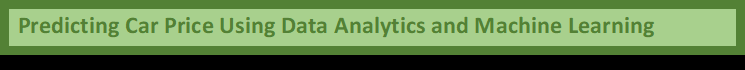

# Importing Libraries

In [461]:
# Import data manipulation libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset

In [462]:
# Load dataset
Auto = pd.read_csv(r"D:\Datas\auto.csv", header=None)

## Assign Column Headers

The dataset initially has no column names, so we assign proper headers.

In [463]:
headers = [
    "symboling","normalized-losses","make","fuel-type","aspiration",
    "num-of-doors","body-style","drive-wheels","engine-location",
    "wheel-base","length","width","height","curb-weight","engine-type",
    "num-of-cylinders","engine-size","fuel-system","bore","stroke",
    "compression-ratio","horsepower","peak-rpm","city-mpg","highway-mpg","price"
]

Auto.columns = headers

## Load first 10 rows

In [464]:
# Load first 10 rows
Auto.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


## Perform descriptive statistics

In [465]:
Auto.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


## Understand Data structure

In [466]:
# Dataset info
Auto.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    str    
 2   make               205 non-null    str    
 3   fuel-type          205 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       205 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

## Identify Unique Values

In [467]:
# Select both object and string datatype columns
categorical_cols = Auto.select_dtypes(include=["object", "string"]).columns

# Print unique values
for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(Auto[col].unique())


Unique values in normalized-losses:
<StringArray>
[  '?', '164', '158', '192', '188', '121',  '98',  '81', '118', '148', '110',
 '145', '137', '101',  '78', '106',  '85', '107', '104', '113', '150', '129',
 '115',  '93', '142', '161', '153', '125', '128', '122', '103', '168', '108',
 '194', '231', '119', '154',  '74', '186',  '83', '102',  '89',  '87',  '77',
  '91', '134',  '65', '197',  '90',  '94', '256',  '95']
Length: 52, dtype: str

Unique values in make:
<StringArray>
[  'alfa-romero',          'audi',           'bmw',     'chevrolet',
         'dodge',         'honda',         'isuzu',        'jaguar',
         'mazda', 'mercedes-benz',       'mercury',    'mitsubishi',
        'nissan',        'peugot',      'plymouth',       'porsche',
       'renault',          'saab',        'subaru',        'toyota',
    'volkswagen',         'volvo']
Length: 22, dtype: str

Unique values in fuel-type:
<StringArray>
['gas', 'diesel']
Length: 2, dtype: str

Unique values in aspiration:
<St

## Task 1: Visualisations (Exploratory Data Analysis)

We now create the required plots:
- Histogram of Price
- Histogram of Horsepower
- Boxplot of Price vs Body Style
- Correlation Heatmap

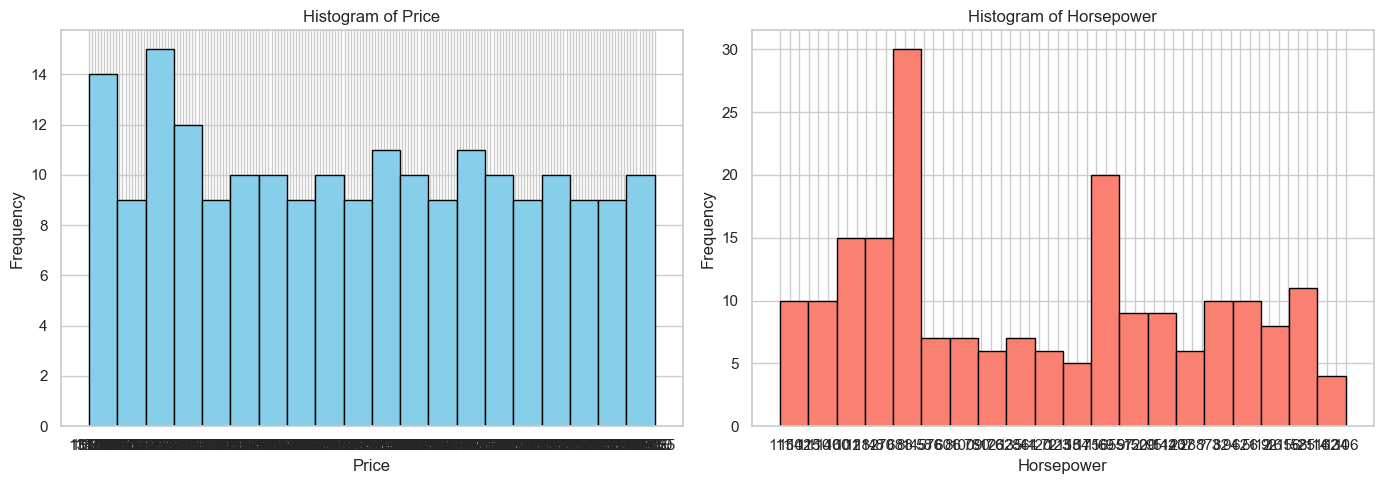

In [468]:
plt.figure(figsize=(14,5))

# Histogram for Price
plt.subplot(1,2,1)
plt.hist(Auto["price"].dropna(), bins=20, color="skyblue", edgecolor="black")
plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

# Histogram for Horsepower
plt.subplot(1,2,2)
plt.hist(Auto["horsepower"].dropna(), bins=20, color="salmon", edgecolor="black")
plt.title("Histogram of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

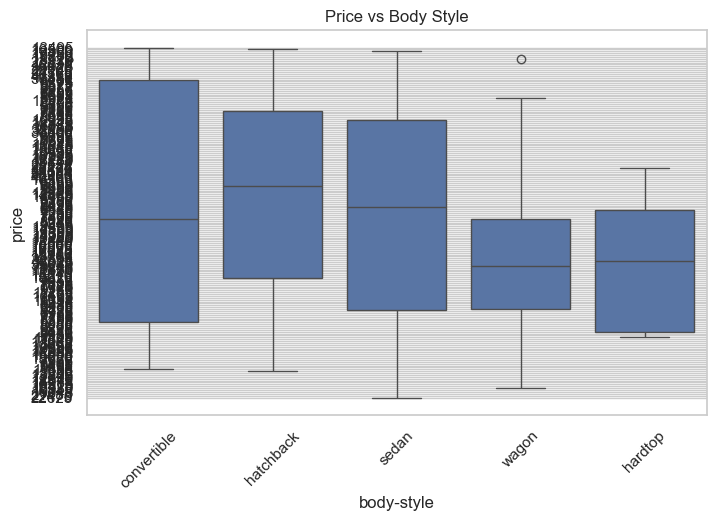

In [469]:
plt.figure(figsize=(8,5))
sns.boxplot(x="body-style", y="price", data=Auto)
plt.title("Price vs Body Style")
plt.xticks(rotation=45)
plt.show()

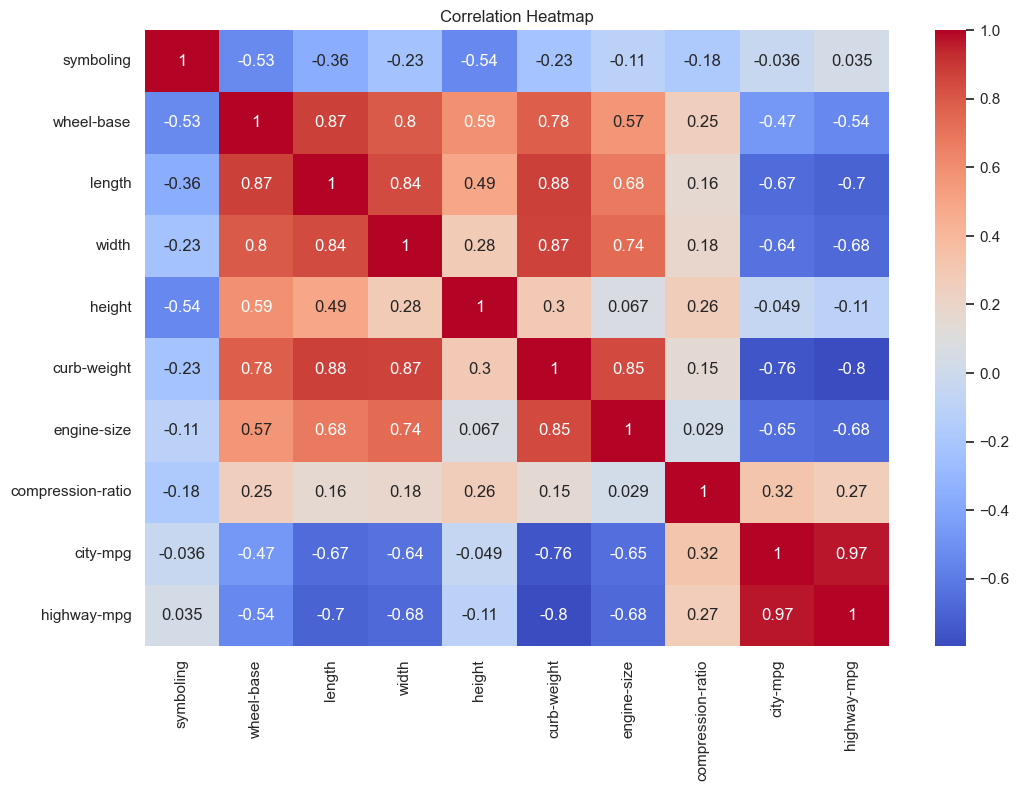

In [470]:
# Select numeric columns only
numeric_df = Auto.select_dtypes(include=["number"])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

The initial visualizations were generated before data preprocessing to understand the raw dataset. After handling missing values and converting data types, the visualizations will be recreated to obtain more reliable insights.

# Task 2: Data Preprocessing & Feature Engineering

In this section, we clean the dataset by:
- Replacing "?" with NaN
- Handling missing values (mean/mode)
- Converting datatypes
- Creating new features
- Binning horsepower
- Normalizing a feature

In [471]:
# Replace "?" with NaN (missing value)
Auto.replace("?", np.nan, inplace=True)

# Check missing values per column
Auto.isnull().sum()

symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64

In [472]:
numeric_cols = [
    "normalized-losses", "bore", "stroke", "horsepower",
    "peak-rpm", "price"
]

# Convert these columns to numeric
for col in numeric_cols:
    Auto[col] = pd.to_numeric(Auto[col], errors="coerce")

In [473]:
# Fill numeric missing values with mean
for col in numeric_cols:
    Auto[col] = Auto[col].fillna(Auto[col].mean())

# Fill categorical missing values with mode
Auto["num-of-doors"] = Auto["num-of-doors"].fillna(Auto["num-of-doors"].mode()[0])

# Check again
Auto.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

# Critical thinking questions

Why is handling missing data important?

Missing values can negatively affect both analysis and machine learning models. If they are not handled properly, statistical calculations may become inaccurate and model predictions may be less reliable. Cleaning missing data helps ensure that the dataset is complete and suitable for analysis.

Which method is better: dropping or replacing? Why?

In this project, replacing missing values was a better choice because dropping rows would have reduced the amount of available data. Since the dataset is not very large, retaining observations through mean and mode imputation helped preserve useful information while maintaining data quality.

In [474]:
# Convert Data types to float
Auto["price"] = Auto["price"].astype(float)
Auto["horsepower"] = Auto["horsepower"].astype(float)

## Task 1 agian
we are going to do the visualization again now (Histogram, Box plot, Correlation Heatmap)

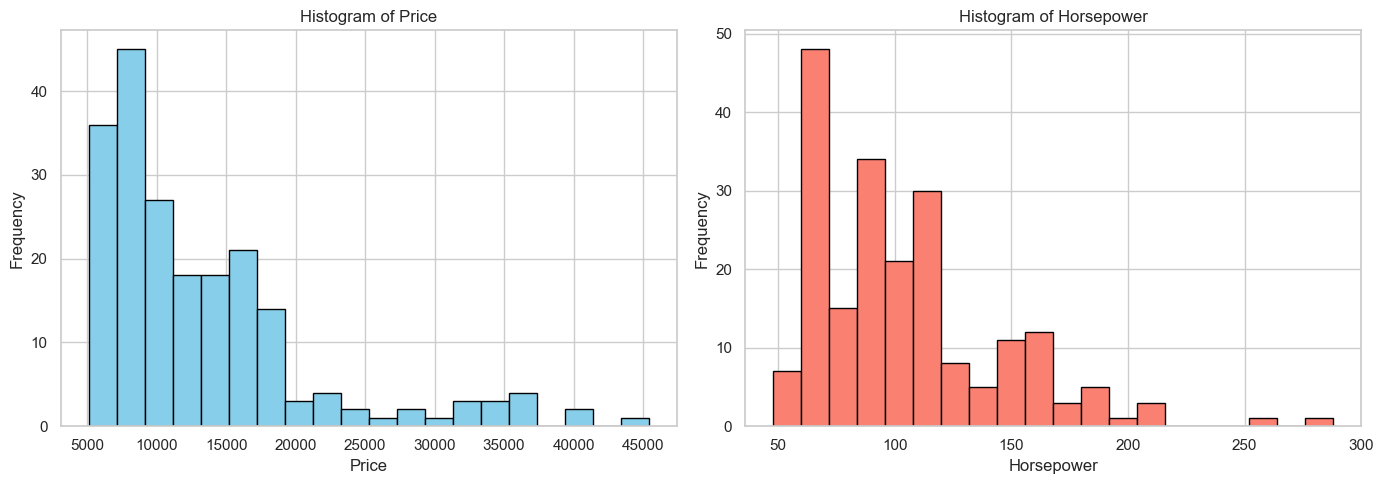

In [475]:
plt.figure(figsize=(14,5))

# Histogram for Price
plt.subplot(1,2,1)
plt.hist(Auto["price"].dropna(), bins=20, color="skyblue", edgecolor="black")
plt.title("Histogram of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

# Histogram for Horsepower
plt.subplot(1,2,2)
plt.hist(Auto["horsepower"].dropna(), bins=20, color="salmon", edgecolor="black")
plt.title("Histogram of Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

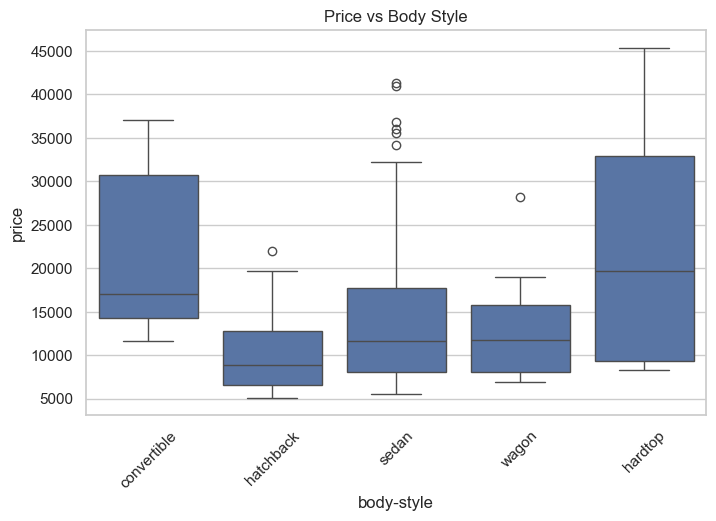

In [476]:
plt.figure(figsize=(8,5))
sns.boxplot(x="body-style", y="price", data=Auto)
plt.title("Price vs Body Style")
plt.xticks(rotation=45)
plt.show()

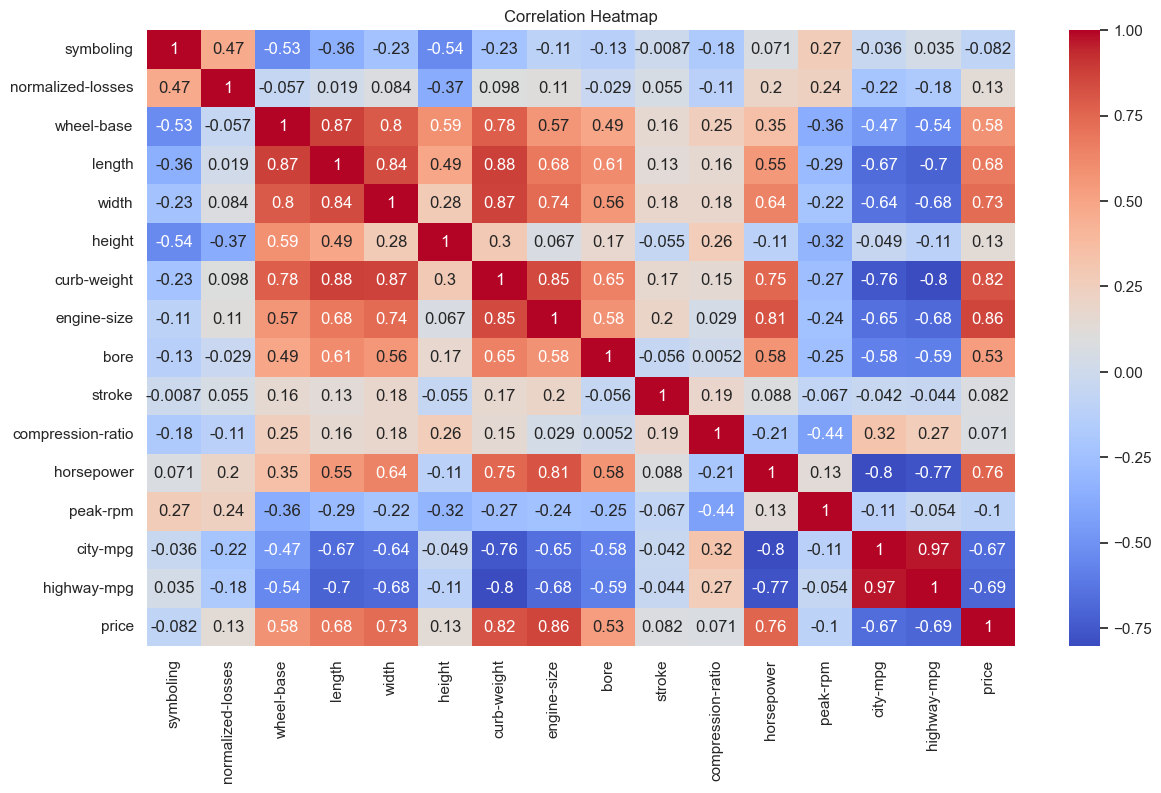

In [477]:
# Select numeric columns only
numeric_df = Auto.select_dtypes(include=["number"])

plt.figure(figsize=(14,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Findings

Engine size and horsepower show strong positive relationships with vehicle price.

Fuel consumption variables also exhibit relationships with price, suggesting that vehicle performance and efficiency influence market value.

These findings support the selection of these variables for predictive modelling.

# Critical thinking questions

What features seem most related to price?

From the correlation analysis, engine size and horsepower appear to have the strongest relationship with vehicle price. Cars with larger engines and greater power tend to be more expensive. Other features such as curb weight and fuel efficiency also show some influence, but their impact is less significant compared to engine-related variables.

Are there any unusual patterns or outliers?

Yes, the dataset contains several high-priced vehicles that stand out from the majority of observations. These are likely premium or luxury models. While they appear as statistical outliers, they represent real vehicles rather than data entry errors, so they provide useful information about the higher end of the automobile market.

Does higher horsepower always mean higher price?

Not necessarily. In general, vehicles with higher horsepower tend to have higher prices because they offer better performance. However, horsepower is not the only factor affecting price. Brand reputation, fuel efficiency, body style, and engine size also contribute to the overall value of a vehicle.

### Outlier Treatment

Outliers were identified using the IQR method and treated using the capping (Winsorization) technique.

In [478]:
columns = ["price", "horsepower", "engine-size"]

for col in columns:
    Q1 = Auto[col].quantile(0.25)
    Q3 = Auto[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = Auto[(Auto[col] < lower) | (Auto[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

price: 14 outliers
horsepower: 6 outliers
engine-size: 10 outliers


In [479]:
for col in columns:
    Q1 = Auto[col].quantile(0.25)
    Q3 = Auto[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    Auto[col] = Auto[col].clip(lower, upper)

## Feature Engineering

In [480]:
# Feature Engineering
Auto["highway-L/100km"] = 235 / Auto["highway-mpg"]
Auto[["highway-mpg", "highway-L/100km"]].head()

,highway-mpg,highway-L/100km
0,27,8.703704
1,27,8.703704
2,26,9.038462
3,30,7.833333
4,22,10.681818


In [481]:
# Feature Engineering
Auto["city-L/100km"] = 235 / Auto["city-mpg"]
Auto[["city-mpg", "city-L/100km"]].head()

,city-mpg,city-L/100km
0,21,11.190476
1,21,11.190476
2,19,12.368421
3,24,9.791667
4,18,13.055556


## Apply binning

In [482]:
bins = [0, 100, 150, Auto["horsepower"].max()]
labels = ["Low", "Medium", "High"]

Auto["horsepower-binned"] = pd.cut(
    Auto["horsepower"], bins=bins, labels=labels, include_lowest=True
)

Auto[["horsepower", "horsepower-binned"]].head()

,horsepower,horsepower-binned
0,111.0,Medium
1,111.0,Medium
2,154.0,High
3,102.0,Medium
4,115.0,Medium


# Critical thinking question

How does binning help analysis?

Binning converts continuous numerical values into meaningful categories. For example, grouping horsepower into low, medium, and high categories makes the data easier to interpret and visualize. It can also simplify classification tasks and help identify broader trends within the dataset.

## Normalized engine-size

In [483]:
Auto["engine-size-normalized"] = Auto["engine-size"] / Auto["engine-size"].max()
Auto[["engine-size", "engine-size-normalized"]].head()

,engine-size,engine-size-normalized
0,130,0.628019
1,130,0.628019
2,152,0.734300
3,109,0.526570
4,136,0.657005


In [484]:
# Select features and target
features = ["engine-size", "horsepower", "city-L/100km", "highway-L/100km"]
X = Auto[features]
y = Auto["price"]

In [485]:
# Split data into training and testing sets (80% train, 20% test)
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression (80/20)

In [486]:
# Create and train the Linear Regression model (80/20)
lr_80 = LinearRegression()
lr_80.fit(X_train_80, y_train_80)

# Predictions (80/20)
y_pred_lr_80 = lr_80.predict(X_test_80)

# Evaluation (80/20)
lr_r2_80 = r2_score(y_test_80, y_pred_lr_80)
lr_mae_80 = mean_absolute_error(y_test_80, y_pred_lr_80)
lr_mse_80 = mean_squared_error(y_test_80, y_pred_lr_80)

print("Linear Regression Results (80/20):")
print("R² Score:", lr_r2_80)
print("MAE:", lr_mae_80)
print("MSE:", lr_mse_80)

Linear Regression Results (80/20):
R² Score: 0.7478805269097566
MAE: 2600.628666210638
MSE: 13100397.619048206


## RandomForest Regressor (80/20)

In [487]:
# Create and train the Random Forest model (80/20)
rf_80 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_80.fit(X_train_80, y_train_80)

# Predictions (80/20)
y_pred_rf_80 = rf_80.predict(X_test_80)

# Evaluation (80/20)
rf_r2_80 = r2_score(y_test_80, y_pred_rf_80)
rf_mae_80 = mean_absolute_error(y_test_80, y_pred_rf_80)
rf_mse_80 = mean_squared_error(y_test_80, y_pred_rf_80)

print("\nRandom Forest Results (80/20):")
print("R² Score:", rf_r2_80)
print("MAE:", rf_mae_80)
print("MSE:", rf_mse_80)


Random Forest Results (80/20):
R² Score: 0.9283961178869289
MAE: 1478.938654052552
MSE: 3720614.339111064


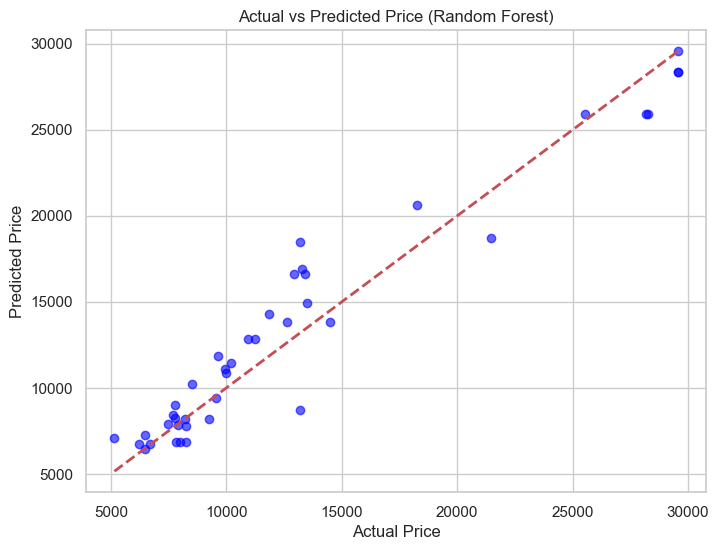

In [488]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_80, y_pred_rf_80,color='blue', alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test_80.min(), y_test_80.max()],
    [y_test_80.min(), y_test_80.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

## Comparison of both models

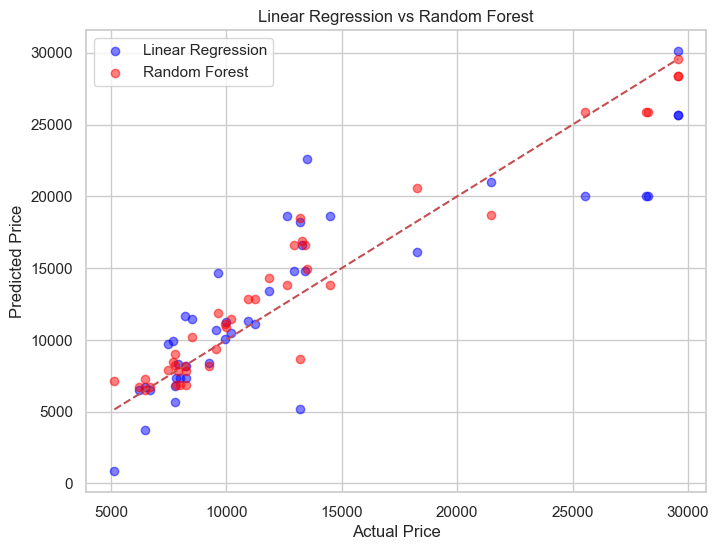

In [489]:
plt.figure(figsize=(8,6))

# Linear Regression
plt.scatter(y_test_80, y_pred_lr_80,color='blue', alpha=0.5, label="Linear Regression")

# Random Forest
plt.scatter(y_test_80, y_pred_rf_80,color='red', alpha=0.5, label="Random Forest")

plt.plot(
    [min(y_test_80), max(y_test_80)],
    [min(y_test_80), max(y_test_80)],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear Regression vs Random Forest")
plt.legend()

plt.show()

# Now we are trying a diffrent split 70/30

In [490]:
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Linear Regression model 70/30

In [491]:
# Train Linear Regression model (70/30)
lr_70 = LinearRegression()
lr_70.fit(X_train_70, y_train_70)

# Predictions (70/30)
y_pred_lr_70 = lr_70.predict(X_test_70)

# Evaluation (70/30)
lr_r2_70 = r2_score(y_test_70, y_pred_lr_70)
lr_mae_70 = mean_absolute_error(y_test_70, y_pred_lr_70)
lr_mse_70 = mean_squared_error(y_test_70, y_pred_lr_70)

print("Linear Regression Results (70/30):")
print("R² Score:", lr_r2_70)
print("MAE:", lr_mae_70)
print("MSE:", lr_mse_70)

Linear Regression Results (70/30):
R² Score: 0.7170204766253411
MAE: 2630.826465130016
MSE: 13047798.283547573


# RandomForest model 70/30

In [492]:
# Train Random Forest model (70/30)
rf_70 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_70.fit(X_train_70, y_train_70)

# Predictions (70/30)
y_pred_rf_70 = rf_70.predict(X_test_70)

# Evaluation (70/30)
rf_r2_70 = r2_score(y_test_70, y_pred_rf_70)
rf_mae_70 = mean_absolute_error(y_test_70, y_pred_rf_70)
rf_mse_70 = mean_squared_error(y_test_70, y_pred_rf_70)

print("\nRandom Forest Results (70/30):")
print("R² Score:", rf_r2_70)
print("MAE:", rf_mae_70)
print("MSE:", rf_mse_70)


Random Forest Results (70/30):
R² Score: 0.8800013063077806
MAE: 1771.8279874193743
MSE: 5532975.428445798


## Bar Chart Comparison of both split 80/20 and 70/30

               Model  Split  R² Score
0  Linear Regression  80/20  0.747881
1      Random Forest  80/20  0.928396
2  Linear Regression  70/30  0.717020
3      Random Forest  70/30  0.880001


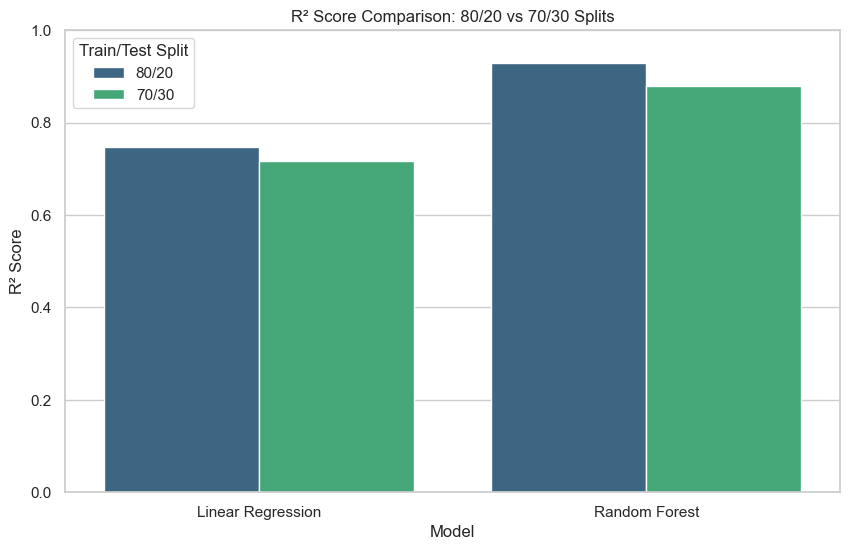

In [493]:
# R² scores
r2_lr_80 = r2_score(y_test_80, y_pred_lr_80)
r2_rf_80 = r2_score(y_test_80, y_pred_rf_80)
r2_lr_70 = r2_score(y_test_70, y_pred_lr_70)
r2_rf_70 = r2_score(y_test_70, y_pred_rf_70)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Linear Regression", "Random Forest"],
    "Split": ["80/20", "80/20", "70/30", "70/30"],
    "R² Score": [r2_lr_80, r2_rf_80, r2_lr_70, r2_rf_70]
})

print(results)

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=results,
    x="Model",
    y="R² Score",
    hue="Split",
    palette="viridis"
)

plt.title("R² Score Comparison: 80/20 vs 70/30 Splits")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.legend(title="Train/Test Split")

plt.show()


From all the Train/Test Split Random Forest(80/20) outperformed all models

# Critical thinking questions

Which model performed better and why?

The Random Forest Regressor performed better than Linear Regression because it was able to capture more complex relationships between the vehicle features and price. Linear Regression assumes a straight-line relationship, while Random Forest can model non-linear patterns that are often present in real-world automobile data.

Does more data always improve performance?

Not always. While larger datasets generally help machine learning models learn better patterns, the quality of the data is equally important. Adding noisy, inaccurate, or irrelevant data may not improve performance and can sometimes reduce model accuracy.

Is the relationship linear or complex?

The results suggest that the relationship between vehicle characteristics and price is more complex than purely linear. Features such as engine size, horsepower, and fuel efficiency interact in different ways, which explains why the Random Forest model performed better than Linear Regression in predicting vehicle prices.

# Task 4: Classification Model

We convert car prices into categories (Low, Medium, High) and build a Logistic Regression model.
We evaluate the model using:
- Accuracy Score
- Confusion Matrix

In [494]:
# Convert price into categories:
Auto["price-category"] = pd.qcut(
    Auto["price"],
    3,
    labels=["Low Price", "Medium Price", "High Price"]
)

In [495]:
X_clf = Auto[["engine-size", "horsepower", "city-L/100km", "highway-L/100km"]]
y_clf = Auto["price-category"]

In [496]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

## Logistic Regression Model

In [497]:
clf_model = LogisticRegression(max_iter=500)
clf_model.fit(X_train_clf, y_train_clf)

# Predictions
y_pred_clf = clf_model.predict(X_test_clf)

# Evaluation: Accuracy + Confusion Matrix
from sklearn.metrics import accuracy_score, confusion_matrix

clf_accuracy = accuracy_score(y_test_clf, y_pred_clf)
clf_cm = confusion_matrix(y_test_clf, y_pred_clf)

print("Classification Accuracy:", clf_accuracy)
print("\nConfusion Matrix:\n", clf_cm)

Classification Accuracy: 0.7317073170731707

Confusion Matrix:
 [[ 9  0  0]
 [ 0 12  3]
 [ 6  2  9]]


D:\Automobile-Price-RegressionJupyterProject3\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


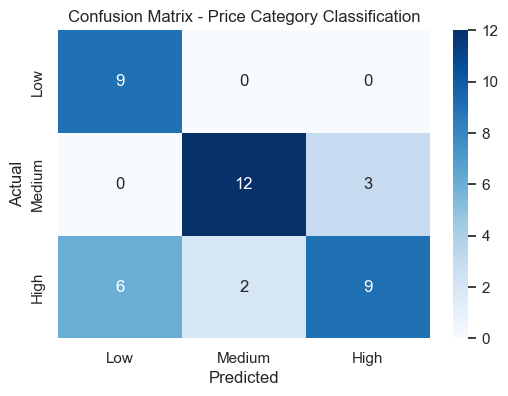

In [498]:
plt.figure(figsize=(6,4))
sns.heatmap(clf_cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])

plt.title("Confusion Matrix - Price Category Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Classification Findings

The Logistic Regression model successfully classified vehicles into low, medium, and high price categories.

The confusion matrix indicates that most vehicles were correctly categorized, demonstrating that vehicle characteristics contain sufficient information to predict price ranges.

## Task 5: Model Evaluation & Visualization Linear Regression (80/20)

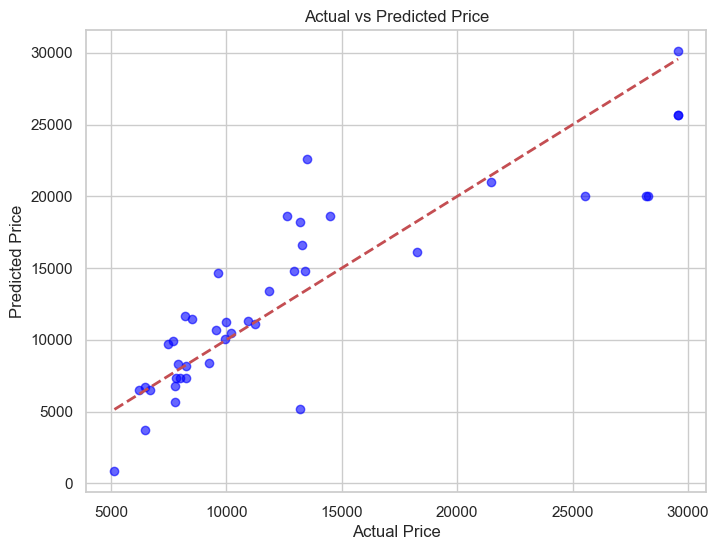

In [499]:
plt.figure(figsize=(8,6))

plt.scatter(y_test_80, y_pred_lr_80, color='blue', alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test_80.min(), y_test_80.max()],
    [y_test_80.min(), y_test_80.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()